In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Import du dataset

In [38]:
import glob

files = glob.glob("../data/eCO2mix_RTE_Annuel-Definitif_*.xls")

dfs = []
for f in files:
    df_temp = pd.read_csv(f, sep="\t", encoding="latin-1", index_col=False)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

C:\Users\trist\AppData\Local\Temp\ipykernel_26464\2610033358.py:7: DtypeWarning: Columns (0:  Stockage batterie, 1: Déstockage batterie, 2: Eolien terrestre, 3: Eolien offshore) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(f, sep="\t", encoding="latin-1", index_col=False)


## Exploration

In [39]:
df.head(10)

,Périmètre,Nature,Date,Heures,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,...,Hydraulique - Fil de l?eau + éclusée,Hydraulique - Lacs,Hydraulique - STEP turbinage,Bioénergies - Déchets,Bioénergies - Biomasse,Bioénergies - Biogaz,Stockage batterie,Déstockage batterie,Eolien terrestre,Eolien offshore
0,France,Données définitives,2020-01-01,00:00,67068.0,68000.0,65800.0,300.0,14.0,6515.0,...,6388.0,2452.0,244.0,517.0,343.0,325.0,ND,ND,ND,ND
1,France,Données définitives,2020-01-01,00:15,NaN,67300.0,65300.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ND,ND,NaN,NaN
2,France,Données définitives,2020-01-01,00:30,66103.0,66600.0,64800.0,107.0,13.0,6692.0,...,6379.0,3111.0,97.0,525.0,344.0,325.0,ND,ND,ND,ND
3,France,Données définitives,2020-01-01,00:45,NaN,65750.0,64000.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ND,ND,NaN,NaN
4,France,Données définitives,2020-01-01,01:00,63943.0,64900.0,63200.0,106.0,13.0,6257.0,...,6155.0,2654.0,324.0,524.0,338.0,325.0,ND,ND,ND,ND
5,France,Données définitives,2020-01-01,01:15,NaN,65200.0,63500.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ND,ND,NaN,NaN
6,France,Données définitives,2020-01-01,01:30,63904.0,65500.0,63800.0,107.0,14.0,5630.0,...,6088.0,2545.0,491.0,525.0,337.0,325.0,ND,ND,ND,ND
7,France,Données définitives,2020-01-01,01:45,NaN,65450.0,63550.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ND,ND,NaN,NaN
8,France,Données définitives,2020-01-01,02:00,63408.0,65400.0,63300.0,107.0,14.0,5337.0,...,6040.0,2522.0,138.0,530.0,344.0,325.0,ND,ND,ND,ND
9,France,Données définitives,2020-01-01,02:15,NaN,64700.0,62450.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ND,ND,NaN,NaN


In [ ]:
# On retire les données au pas 00:15 et 00:45 car les données définitives fonctionnent en pas de 30 minutes
df = df.dropna(subset=["Consommation"])

In [41]:
df.head(10)

,Périmètre,Nature,Date,Heures,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,...,Hydraulique - Fil de l?eau + éclusée,Hydraulique - Lacs,Hydraulique - STEP turbinage,Bioénergies - Déchets,Bioénergies - Biomasse,Bioénergies - Biogaz,Stockage batterie,Déstockage batterie,Eolien terrestre,Eolien offshore
0,France,Données définitives,2020-01-01,00:00,67068.0,68000.0,65800.0,300.0,14.0,6515.0,...,6388.0,2452.0,244.0,517.0,343.0,325.0,ND,ND,ND,ND
2,France,Données définitives,2020-01-01,00:30,66103.0,66600.0,64800.0,107.0,13.0,6692.0,...,6379.0,3111.0,97.0,525.0,344.0,325.0,ND,ND,ND,ND
4,France,Données définitives,2020-01-01,01:00,63943.0,64900.0,63200.0,106.0,13.0,6257.0,...,6155.0,2654.0,324.0,524.0,338.0,325.0,ND,ND,ND,ND
6,France,Données définitives,2020-01-01,01:30,63904.0,65500.0,63800.0,107.0,14.0,5630.0,...,6088.0,2545.0,491.0,525.0,337.0,325.0,ND,ND,ND,ND
8,France,Données définitives,2020-01-01,02:00,63408.0,65400.0,63300.0,107.0,14.0,5337.0,...,6040.0,2522.0,138.0,530.0,344.0,325.0,ND,ND,ND,ND
10,France,Données définitives,2020-01-01,02:30,62711.0,64000.0,61600.0,107.0,15.0,4495.0,...,6012.0,2058.0,142.0,524.0,335.0,326.0,ND,ND,ND,ND
12,France,Données définitives,2020-01-01,03:00,60825.0,62000.0,59700.0,107.0,14.0,3660.0,...,5897.0,1643.0,118.0,530.0,331.0,325.0,ND,ND,ND,ND
14,France,Données définitives,2020-01-01,03:30,59332.0,60500.0,58300.0,107.0,14.0,2942.0,...,5754.0,1432.0,149.0,533.0,337.0,325.0,ND,ND,ND,ND
16,France,Données définitives,2020-01-01,04:00,58004.0,59100.0,57100.0,107.0,13.0,2942.0,...,5624.0,1397.0,0.0,538.0,339.0,325.0,ND,ND,ND,ND
18,France,Données définitives,2020-01-01,04:30,57125.0,58200.0,56200.0,107.0,14.0,2963.0,...,5508.0,1099.0,0.0,537.0,338.0,324.0,ND,ND,ND,ND


In [42]:
df.describe()

,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,Nucléaire,Eolien,Solaire,Hydraulique,...,Gaz - TAC,Gaz - Cogén.,Gaz - CCG,Gaz - Autres,Hydraulique - Fil de l?eau + éclusée,Hydraulique - Lacs,Hydraulique - STEP turbinage,Bioénergies - Déchets,Bioénergies - Biomasse,Bioénergies - Biogaz
count,87696.000000,87696.000000,87696.000000,87696.000000,87696.000000,87696.000000,87696.000000,87696.000000,87696.000000,87696.000000,...,87696.000000,87696.000000,87696.000000,87696.000000,87696.000000,87696.000000,87696.000000,87696.000000,87696.000000,87696.000000
mean,51127.124829,50469.428799,50377.582661,113.803469,219.235142,3596.321394,37776.351909,4860.836241,2098.971698,7029.912596,...,68.099697,899.831703,2286.074074,342.545430,4551.683235,1829.171410,649.071007,487.095489,343.602262,336.408525
std,10993.154988,11026.923343,11024.104372,136.081038,404.605218,2530.043143,7093.524874,3784.672587,3107.655532,2841.779174,...,99.844591,802.762116,1871.738325,455.508552,1454.310601,1200.470258,738.105717,44.768244,55.412020,12.331009
min,29124.000000,27500.000000,0.000000,27.000000,0.000000,260.000000,19164.000000,60.000000,0.000000,1532.000000,...,0.000000,186.000000,0.000000,14.000000,1211.000000,46.000000,0.000000,328.000000,181.000000,260.000000
25%,42984.750000,42300.000000,42300.000000,72.000000,14.000000,1421.000000,32197.000000,1948.000000,0.000000,4871.000000,...,4.000000,329.000000,403.000000,57.000000,3360.750000,920.000000,84.000000,460.000000,305.000000,328.000000
50%,49362.000000,48600.000000,48600.000000,84.000000,19.000000,3210.000000,38497.000000,3685.000000,45.000000,6764.000000,...,37.000000,470.000000,2154.000000,99.000000,4681.000000,1584.000000,380.000000,490.000000,336.000000,337.000000
75%,58318.500000,57600.000000,57400.000000,100.000000,317.000000,5156.000000,42685.000000,6870.250000,3675.000000,8755.000000,...,94.000000,1199.000000,3848.000000,393.250000,5728.000000,2436.000000,986.000000,518.000000,377.000000,345.000000
max,88416.000000,88000.000000,88500.000000,1734.000000,2311.000000,10591.000000,54720.000000,19744.000000,16658.000000,17947.000000,...,790.000000,3385.000000,6580.000000,1772.000000,8430.000000,7211.000000,4294.000000,2655.000000,661.000000,448.000000


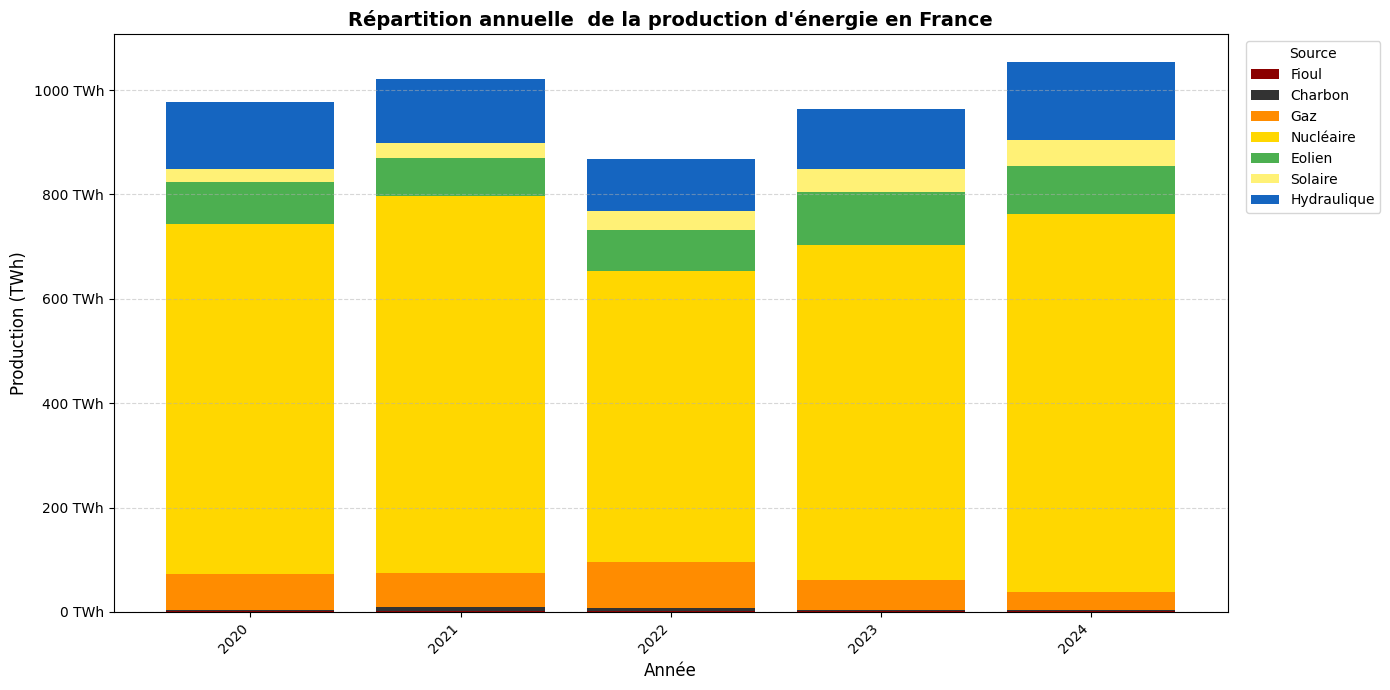

In [43]:
df_explo = df.copy()

df_explo["Date"] = pd.to_datetime(df_explo["Date"])
df_explo["Année"] = df_explo["Date"].dt.to_period("Y")

energy_cols = ["Fioul", "Charbon", "Gaz", "Nucléaire", "Eolien", "Solaire", "Hydraulique"]

annually = df_explo.groupby("Année")[energy_cols].sum()

# Convertir en TWh pour lisibilité
annually_twh = annually / 1e6

fig, ax = plt.subplots(figsize=(14, 7))

colors = ["#8B0000", "#333333", "#FF8C00", "#FFD700", "#4CAF50", "#FFF176", "#1565C0"]

annually_twh.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.8)

ax.set_title("Répartition annuelle  de la production d'énergie en France", fontsize=14, fontweight="bold")
ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("Production (TWh)", fontsize=12)
ax.set_xticklabels([str(m) for m in annually_twh.index], rotation=45, ha="right")
ax.legend(title="Source", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f} TWh"))
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
#plt.savefig("production_annuelle.png", dpi=150)
plt.show()

## Datacard

In [44]:
from datetime import datetime
import yaml

In [ ]:
n = len(df)

datacard = {
    "name": "eCO2mix_RTE_Annuel-Definitif",
    "version": "1.0",
    "created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "domain": "energy",
    "period": "2020-2024",
    "data": {
        "instance_count": n,
        "feature_count": df.shape[1],
        "feature_list": {},
    }
}

description = {
    "Périmètre": "France",
    "Nature": "Données temps réel / Données consolidées / Données définitives",
    "Date": "Date du jour (jj/mm/aaaa)",
    "Heures": "Point horaire par pas de 30 minutes (hh:mm)",
    "Consommation": "Consommation en MW",
    "Prévision J-1": "Prévision J-1 de consommation en MW",
    "Prévision J": "Prévision J de consommation en MW",
    "Fioul": "Production fioul en MW",
    "Charbon": "Production charbon en MW",
    "Gaz": "Production gaz en MW",
    "Nucléaire": "Production nucléaire en MW",
    "Eolien": "Production éolienne en MW",
    "Solaire": "Production solaire en MW",
    "Hydraulique": "Production hydraulique en MW",
    "Pompage": "Pompage hydraulique en MW",
    "Bioénergies": "Production Bioénergies en MW",
    "Ech. physiques": "Solde imports/exports (flux physiques) en MW",
    "Taux de CO2": "Estimation des émissions de CO2 en g/kWh",
    "Ech. comm. Angleterre": "Solde imports/exports Angleterre (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Espagne": "Solde imports/exports Espagne (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Italie": "Solde imports/exports Italie (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Suisse": "Solde imports/exports Suisse (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Allemagne-Belgique": "Solde imports/exports Allemagne-Belgique (programmes d'échanges commerciaux) en MW",
    "Fioul - TAC": "Détail technologie turbine à combustion pour la filière fioul",
    "Fioul - Cogén.": "Détail technologie cogénération pour la filière fioul",
    "Fioul - Autres": "Détail autres technologies pour la filière fioul",
    "Gaz - TAC": "Détail technologie turbine à combustion pour la filière gaz",
    "Gaz - Cogén.": "Détail technologie cogénération pour la filière gaz",
    "Gaz - CCG": "Détail technologie cycle combiné gaz pour la filière gaz",
    "Gaz - Autres": "Détail autres technologies pour la filière gaz",
    "Hydraulique - Fil de l'eau + éclusée": "Détail technologie fil de l'eau et éclusée pour la filière hydraulique",
    "Hydraulique - Lacs": "Détail technologie lacs pour la filière hydraulique",
    "Hydraulique - STEP turbinage": "Détail technologie STEP turbinage pour la filière hydraulique",
    "Bioénergies - Déchets": "Détail technologie déchets pour la filière Bioénergies",
    "Bioénergies - Biomasse": "Détail technologie biomasse pour la filière Bioénergies",
    "Bioénergies - Biogaz": "Détail technologie biogaz pour la filière Bioénergies",
    "Stockage batterie": "Détail soutirage batteries",
    "Déstockage batterie": "Détail injections batteries",
    "Eolien terrestre": "Détail technologie éolien terrestre pour la filière Eolien",
    "Eolien offshore": "Détail technologie éolien en mer pour la filière Eolien",
}

count = df.count()
nunique = df.nunique()
missing = df.isna().sum()

df_stats = pd.DataFrame({
    "count": count.astype(int),
    "unique_count": nunique.astype(int),
    "duplicate_count": (count - nunique).astype(int),
    "duplicate_ratio": ((count - nunique) / count).round(2).astype(float),
    "missing_count": missing.astype(int),
    "missing_ratio": (missing / n).round(2).astype(float),
})
describe = df.describe().astype(float)

for idx, row in df_stats.iterrows():
    card = {
        "description": description.get(idx, ""),
        "type": str(df[idx].dtypes),
        "stats": row.to_dict(),
        "sample": df[idx].dropna().unique()[:5].tolist()
    }

    if pd.api.types.is_numeric_dtype(df[idx]):
        card.update({
            'stats': {
                **row.to_dict(),
                **describe[idx].to_dict()
            }
        })

    datacard["data"]["feature_list"][idx] = card

In [46]:
with open("../data/raw_data.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(datacard, f, sort_keys=False, allow_unicode=True)